### TASK.

Extract the **List of countries and territories by total population** table from the **List of countries and dependencies by population** wikipedia page. Use a pie chart to visualize the distribution of the count of  **Sources** used in stating country populations.

#### 1.0 Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

#### 2.0 Checking for existing tables from the URL.

In [110]:
url = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"
tables = pd.read_html(url)
len(tables)

3

#### 3.0 Identification of table of interest.

In [60]:
tables[0]

,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8161973000,100%,1 Jul 2024,UN projection[1][3],NaN
1,India,1413324000,17.3%,1 Mar 2025,Official projection[4],[b]
2,China,1408280000,17.2%,31 Dec 2024,Official estimate[5],[c]
3,United States,340110988,4.2%,1 Jul 2024,Official estimate[6],[d]
4,Indonesia,282477584,3.5%,30 Jun 2024,National annual projection[7],NaN
...,...,...,...,...,...,...
235,Niue (New Zealand),1681,0%,11 Nov 2022,2022 Census[246],NaN
236,Tokelau (New Zealand),1647,0%,1 Jan 2019,2019 Census[247],NaN
237,Vatican City,882,0%,31 Dec 2024,Official figure[248],[ah]
238,Cocos (Keeling) Islands (Australia),593,0%,30 Jun 2020,2021 Census[249],NaN


##### 3.1 Variable assignment to the table of interest

In [111]:
df = tables[0]
df.head()

,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8161973000,100%,1 Jul 2024,UN projection[1][3],NaN
1,India,1413324000,17.3%,1 Mar 2025,Official projection[4],[b]
2,China,1408280000,17.2%,31 Dec 2024,Official estimate[5],[c]
3,United States,340110988,4.2%,1 Jul 2024,Official estimate[6],[d]
4,Indonesia,282477584,3.5%,30 Jun 2024,National annual projection[7],NaN


#### 4.0 Creating a dataframe copy. 

In [112]:
df2 = df.copy()
df2.head()

,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8161973000,100%,1 Jul 2024,UN projection[1][3],NaN
1,India,1413324000,17.3%,1 Mar 2025,Official projection[4],[b]
2,China,1408280000,17.2%,31 Dec 2024,Official estimate[5],[c]
3,United States,340110988,4.2%,1 Jul 2024,Official estimate[6],[d]
4,Indonesia,282477584,3.5%,30 Jun 2024,National annual projection[7],NaN


##### 5.0 Dropping uninterested columns

In [114]:
df2.drop(['Location','Population', '% of world', 'Date', 'Notes'], axis=1, inplace=True)

##### 6.0 Renaming the Column

In [115]:
df2.rename(columns= {'Source (official or from the United Nations)':'Source'}, inplace=True)
df2.head()

,Source
0,UN projection[1][3]
1,Official projection[4]
2,Official estimate[5]
3,Official estimate[6]
4,National annual projection[7]


##### 7.0 Spliting the values at whitespaces and special characters.

In [73]:
source_txt = df2['Source'].str.split(r'\s*\[.*?\]\s*', expand=True)

In [74]:
source_txt.head()

,0,1,2,3
0,UN projection,,,None
1,Official projection,,None,None
2,Official estimate,,None,None
3,Official estimate,,None,None
4,National annual projection,,None,None


##### 8.0 Dropping the split columns.

In [79]:
source_txt.drop([1,2,3], axis=1, inplace=True)

##### 9.0 Renaming the column

In [80]:
source_txt.rename(columns={0:'Source'}, inplace=True)

In [87]:
source_txt.head()

,Source
0,UN projection
1,Official projection
2,Official estimate
3,Official estimate
4,National annual projection


##### 10.0 Checking for null values

In [88]:
source_txt.isnull().sum()

Source    0
dtype: int64

##### 11.0 Grouping the distinct values and their counts.

In [116]:
grouped_df = source_txt.groupby('Source').size().reset_index(name='Count')

In [94]:
grouped_df.head()

,Source,Count
0,,1
1,2019 Census,1
2,2020 census result,4
3,2021 Census,8
4,2021 census result,5


##### 12.0 Ploting the Pie chart.

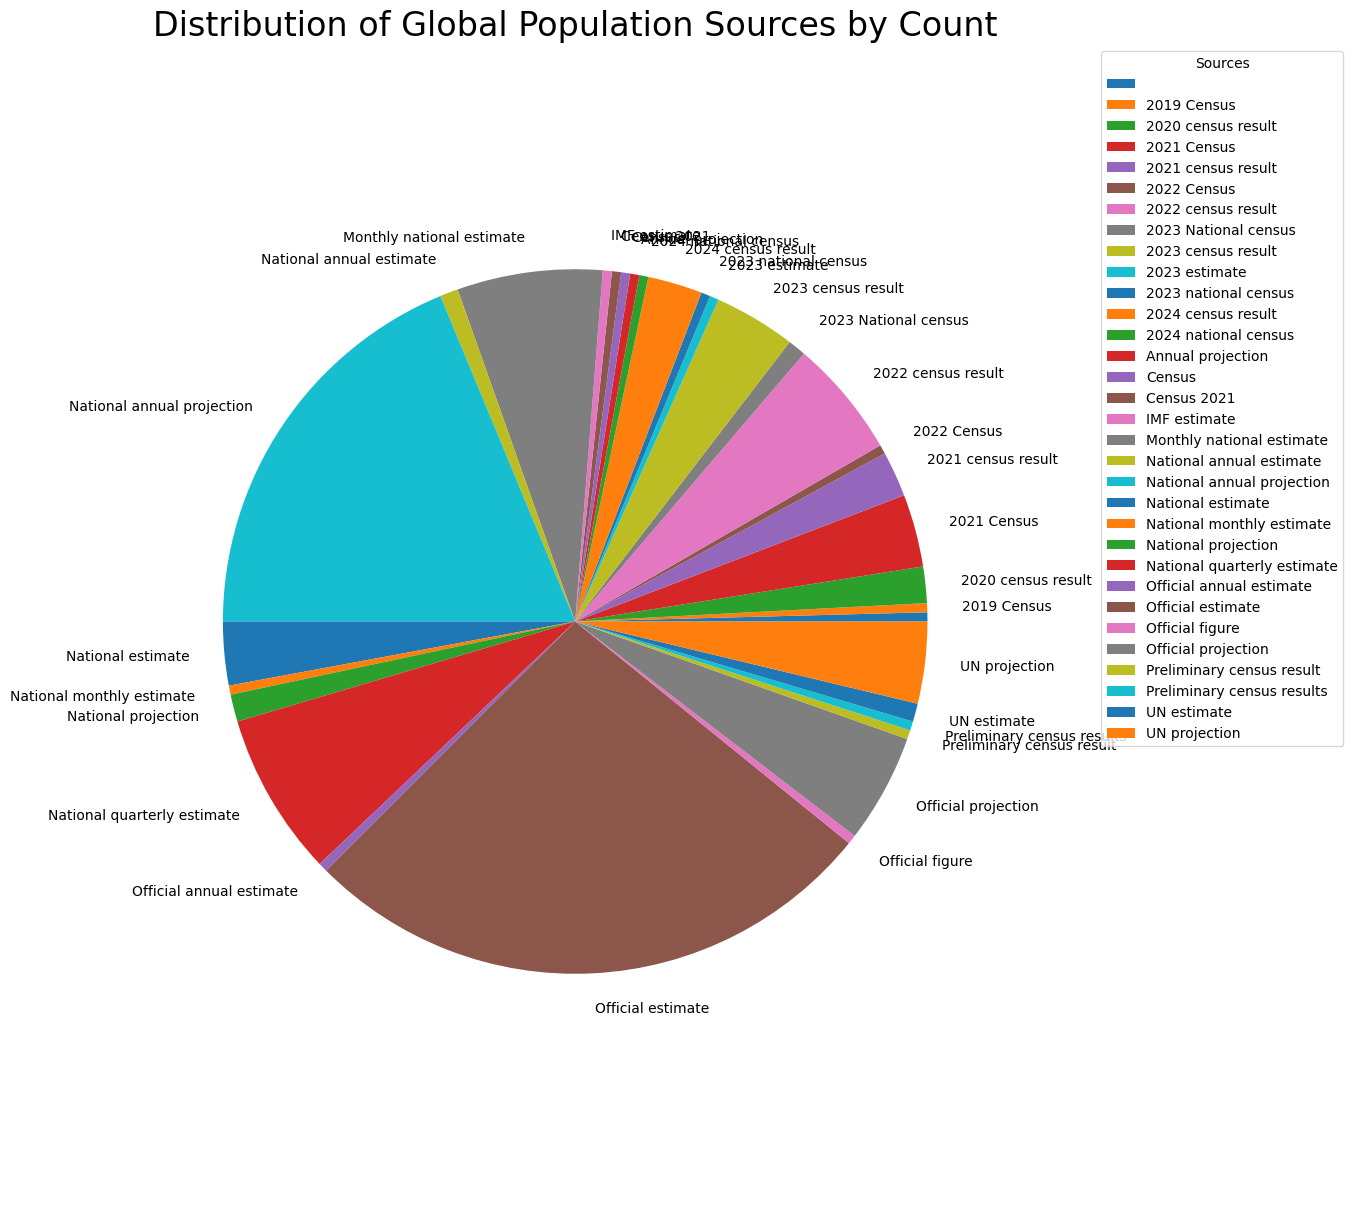

In [121]:
plt.figure(figsize=(10,15))
plt.pie(grouped_df['Count'], labels=grouped_df['Source'])
plt.title('Distribution of Global Population Sources by Count', fontsize=24)
plt.legend(title='Sources', labels=grouped_df['Source'], loc="best", bbox_to_anchor=(1, 0, 0.5, 1))
plt.axis('equal')
plt.show()